# Variables categóricas: frecuencias y proporciones
Evaluamos la distribución de los eventos por departamento para destacar qué territorios concentran
la carga de divorcios y delitos.


## Objetivos
- Calcular la participación porcentual por departamento (suma 2014-2024).
- Visualizar los cinco primeros territorios por cada dataset.
- Documentar hallazgos sobresalientes para priorizar políticas.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Iterable, Optional

sns.set_style("ticks")

DATASETS = {
    "divorcios": "Divorcios 2001 a 2024.csv",
    "delitos_total": "Delitos 2014 a 2024.csv",
    "otros_delitos": "Otros delitos 2014 a 2024.csv",
    "delincuencia": "Proyecto1(Delitos 2014 a 2024 Delincuenci).csv",
    "narcos": "Proyecto1(Delitos 2014 a 2024 NARCOS).csv",
    "ramo_penal": "Proyecto1(Ramo Penal 2014 a 2024).csv",
}

pd.options.display.float_format = "{:.2f}".format

def _resolve_data_dir() -> Path:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        candidate = root / "datos"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No se encontró la carpeta 'datos'.")

DATA_DIR = _resolve_data_dir()

def load_long_form(dataset_subset: Optional[Iterable[str]] = None) -> pd.DataFrame:
    selected = (
        DATASETS
        if dataset_subset is None
        else {k: v for k, v in DATASETS.items() if k in set(dataset_subset)}
    )
    tables = []
    for name, filename in selected.items():
        df = pd.read_csv(
            DATA_DIR / filename,
            sep=";",
            thousands=".",
            decimal=",",
            encoding="latin-1",
            engine="python",
        )
        df.columns = df.columns.str.strip()
        df["Departamento"] = df["Departamento"].str.strip()
        year_cols = [col for col in df.columns if col.strip().isdigit()]
        long_df = (
            df.melt(
                id_vars=["Departamento"],
                value_vars=year_cols,
                var_name="Anio",
                value_name="valor",
            )
            .assign(dataset=name)
            .dropna(subset=["valor"])
        )
        long_df["Anio"] = pd.to_numeric(long_df["Anio"], errors="coerce")
        long_df["valor"] = pd.to_numeric(long_df["valor"], errors="coerce")
        tables.append(long_df.dropna(subset=["Anio", "valor"]))

    data = pd.concat(tables, ignore_index=True)
    data["Departamento"] = (
        data["Departamento"]
        .str.replace("pa�s", "país", regex=False)
        .str.replace("pa�", "pa", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    mask_total = data["Departamento"].str.contains("total", case=False, na=False)
    mask_todos = data["Departamento"].str.contains("todos", case=False, na=False)
    return data.loc[~(mask_total | mask_todos)].reset_index(drop=True)

all_data = load_long_form()
print(all_data.head())


    Departamento  Anio  valor    dataset
0      Guatemala  2001 277.00  divorcios
1    El Progreso  2001  16.00  divorcios
2   Sacatepéquez  2001  25.00  divorcios
3  Chimaltenango  2001   6.00  divorcios
4      Escuintla  2001   2.00  divorcios


In [2]:
totals = all_data.groupby(["dataset", "Departamento"], as_index=False)["valor"].sum()
totals["participacion_pct"] = totals.groupby("dataset")["valor"].transform(
    lambda s: 100 * s / s.sum()
)

labels = {
    "divorcios": "Divorcios",
    "delitos_total": "Delitos totales",
    "otros_delitos": "Otros delitos",
    "delincuencia": "Delincuencia común",
    "narcos": "Delitos narcotráfico",
    "ramo_penal": "Ramo penal",
}
totals["dataset_label"] = totals["dataset"].map(labels)

shares_top5 = totals.sort_values(["dataset", "participacion_pct"], ascending=[True, False]).groupby(
    "dataset", as_index=False
).head(5)

shares_top5[["dataset_label", "Departamento", "participacion_pct"]].round(2)


,dataset_label,Departamento,participacion_pct
6,Delincuencia común,Guatemala,84.71
12,Delincuencia común,Quetzaltenango,5.41
2,Delincuencia común,Chimaltenango,3.17
8,Delincuencia común,Izabal,2.00
0,Delincuencia común,Alta Verapaz,0.90
28,Delitos totales,Guatemala,42.05
34,Delitos totales,Quetzaltenango,6.57
30,Delitos totales,Izabal,5.75
22,Delitos totales,Alta Verapaz,4.58
29,Delitos totales,Huehuetenango,4.48


C:\Users\viank\AppData\Local\Temp\ipykernel_20020\3158990914.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


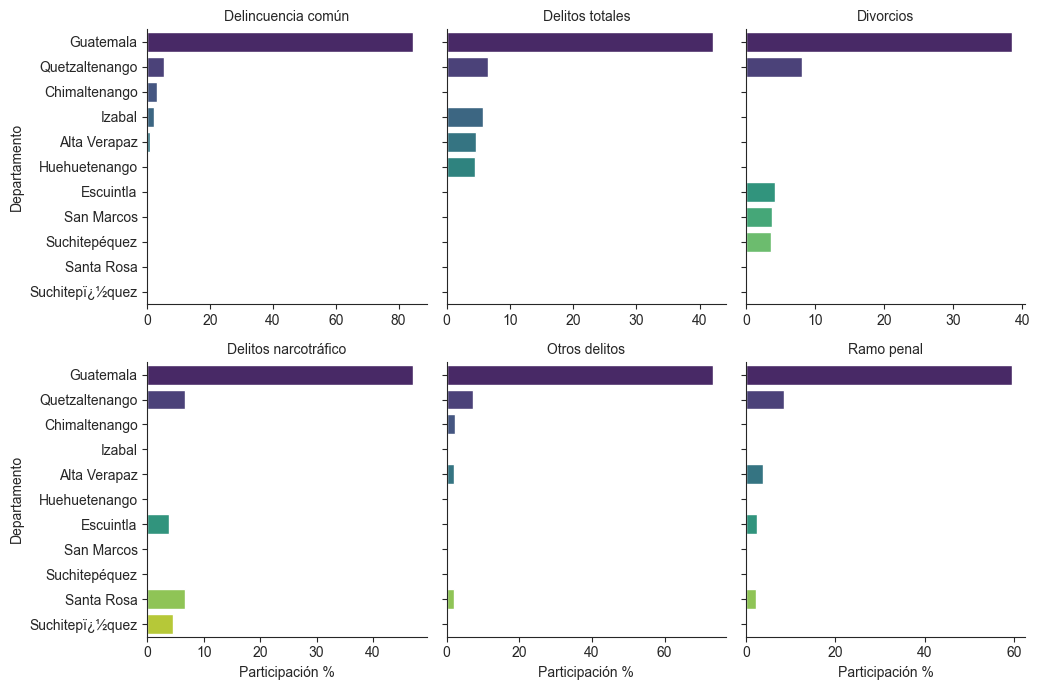

In [3]:
g = sns.catplot(
    data=shares_top5,
    x="participacion_pct",
    y="Departamento",
    col="dataset_label",
    kind="bar",
    col_wrap=3,
    height=3.5,
    sharex=False,
    palette="viridis",
)
g.set_titles("{col_name}")
g.set_xlabels("Participación %")
plt.tight_layout()


## Observaciones
- Guatemala concentra entre 38% (`Divorcios`) y 73% (`Otros delitos`) del total nacional, por lo que
  cualquier intervención nacional pasa obligatoriamente por la capital.
- Quetzaltenango aparece dentro del top 3 en todos los conjuntos, consolidándose como segundo polo.
- Santa Rosa y Escuintla sólo destacan en delitos de narcotráfico y ramo penal, señalando focos
  específicos más que un patrón generalizado.
- Departamentos rurales como Alta Verapaz participan con ~4% en `Ramo penal` y `Otros delitos`, lo que
  sugiere dinámicas locales relevantes pese a su menor tamaño poblacional.
